# Model Experiments on Original Normalized Data (n = 1481)

This notebook runs all classification models on the GAN-augmented balanced normalized dataset.

## Models:
1. Random Forest Classifier
2. Gradient Boosting Classifier
3. XGBoost Classifier
4. CatBoost Classifier
5. Logistic Regression
6. Artificial Neural Network (PyTorch)

## Target: Current_CGPA5 (5 classes)
- Class 0 (normalized: 0.0) = CGPA 3.6-4.0
- Class 1 (normalized: 0.25) = CGPA 3.2-3.59
- Class 2 (normalized: 0.5) = CGPA 2.8-3.19
- Class 3 (normalized: 0.75) = CGPA 2.4-2.79
- Class 4 (normalized: 1.0) = CGPA <2.4

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Train-Test Split and Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score
)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("All libraries imported successfully!")

Using device: cuda
All libraries imported successfully!


## 2. Load Balanced Normalized Data

In [2]:
# Load the GAN-augmented balanced normalized data
df = pd.read_csv(r'../data/Final_Encoded_Normalized.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (1481, 31)

Columns: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Current_CGPA5', 'CGPA3_Class', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


,Age,Gender,Where_live,AVG_Sleep_Per_Night,Regular_Bed_time,Exam_Night_Bed_Time,Holiday_Bed_Time,Regular_WakeUp_Time,Holiday_WakeUp_Time,Have_Regular_Bed_Time,...,Class_Attendance,Sleepiness_During_Class,Skip_Class_for_Sleep,Focus_on_Academic_Task,Impact_of_Sleep_on_Academic,Current_CGPA5,CGPA3_Class,Aware_of_Recomamended_Sleep,Use_Sleep_Tracking_Devices,Sacrifices_Sleep_for_Academics
0,0.666667,1.0,0.0,1.000000,1.00,1.00,1.00,1.0,1.0,0.0,...,0.333333,0.666667,0.0,0.0,0.75,0.50,0.5,1.0,0.0,1.0
1,0.666667,0.0,0.5,0.333333,0.75,0.25,0.25,0.5,1.0,0.0,...,0.333333,0.000000,1.0,0.5,0.75,0.75,0.5,1.0,0.0,1.0
2,0.666667,0.0,0.5,0.000000,1.00,1.00,1.00,0.5,1.0,0.0,...,0.000000,0.000000,1.0,0.0,0.00,0.75,0.5,1.0,0.0,1.0
3,1.000000,0.0,0.5,0.666667,0.50,0.75,1.00,0.5,1.0,0.0,...,0.000000,0.000000,0.0,1.0,0.25,0.75,0.5,1.0,0.0,1.0
4,0.666667,0.0,0.0,0.333333,0.75,0.75,0.75,0.5,0.5,0.0,...,1.000000,0.333333,0.0,0.5,0.25,0.75,0.5,0.0,0.0,1.0


In [3]:
# Check class distribution
TARGET_COLUMN = 'Current_CGPA5'

print("Class Distribution (Normalized Values):")
print(df[TARGET_COLUMN].value_counts().sort_index())

# Convert normalized target back to integer classes for modeling
# 0.0 -> 0, 0.25 -> 1, 0.5 -> 2, 0.75 -> 3, 1.0 -> 4
df['Target'] = (df[TARGET_COLUMN] * 4).round().astype(int)

print("\nConverted Target Classes:")
print(df['Target'].value_counts().sort_index())
print("\n0 = CGPA 3.6-4.0 (Excellent)")
print("1 = CGPA 3.2-3.59 (Very Good)")
print("2 = CGPA 2.8-3.19 (Good)")
print("3 = CGPA 2.4-2.79 (Satisfactory)")
print("4 = CGPA <2.4 (Poor)")

Class Distribution (Normalized Values):
Current_CGPA5
0.00    309
0.25    346
0.50    315
0.75    293
1.00    218
Name: count, dtype: int64

Converted Target Classes:
Target
0    309
1    346
2    315
3    293
4    218
Name: count, dtype: int64

0 = CGPA 3.6-4.0 (Excellent)
1 = CGPA 3.2-3.59 (Very Good)
2 = CGPA 2.8-3.19 (Good)
3 = CGPA 2.4-2.79 (Satisfactory)
4 = CGPA <2.4 (Poor)


## 3. Prepare Features and Target

In [4]:
# Define features (exclude target columns)
exclude_cols = ['CGPA3_Class', 'Target', 'Current_CGPA5']  # Exclude target and related columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of features: 29
Features: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


In [5]:
# Prepare X and y
X = df[feature_cols].values
y = df['Target'].values

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_test)*100:.1f}%)")

Training set: 1184 samples
Test set: 297 samples

Training class distribution:
  Class 0: 247 (20.9%)
  Class 1: 277 (23.4%)
  Class 2: 252 (21.3%)
  Class 3: 234 (19.8%)
  Class 4: 174 (14.7%)

Test class distribution:
  Class 0: 62 (20.9%)
  Class 1: 69 (23.2%)
  Class 2: 63 (21.2%)
  Class 3: 59 (19.9%)
  Class 4: 44 (14.8%)


## 4. Helper Functions

In [6]:
# Store all results
all_results = []

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate model and return metrics
    """
    y_pred = model.predict(X_test)
    
    # For models that support predict_proba
    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    except:
        roc_auc = None
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    result = {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Macro F1-Score': round(macro_f1, 4),
        'Balanced Accuracy': round(balanced_acc, 4),
        'ROC-AUC': round(roc_auc, 4) if roc_auc else 'N/A'
    }
    
    all_results.append(result)
    return result, y_pred

def plot_confusion_matrix(y_test, y_pred, model_name):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    class_labels = ['Excellent\n(3.6-4.0)', 'Very Good\n(3.2-3.59)', 'Good\n(2.8-3.19)', 
                    'Satisfactory\n(2.4-2.79)', 'Poor\n(<2.4)']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_test, y_pred, model_name):
    """
    Print classification report
    """
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print('='*60)
    print(classification_report(y_test, y_pred, 
          target_names=['Excellent (3.6-4.0)', 'Very Good (3.2-3.59)', 'Good (2.8-3.19)', 
                        'Satisfactory (2.4-2.79)', 'Poor (<2.4)']))

---
## 5. Model 1: Random Forest Classifier

In [7]:
print("Training Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
result, y_pred_rf = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Random Forest Classifier...

Results:
  Model: Random Forest
  Accuracy: 0.2458
  Macro F1-Score: 0.2351
  Balanced Accuracy: 0.241
  ROC-AUC: 0.5675


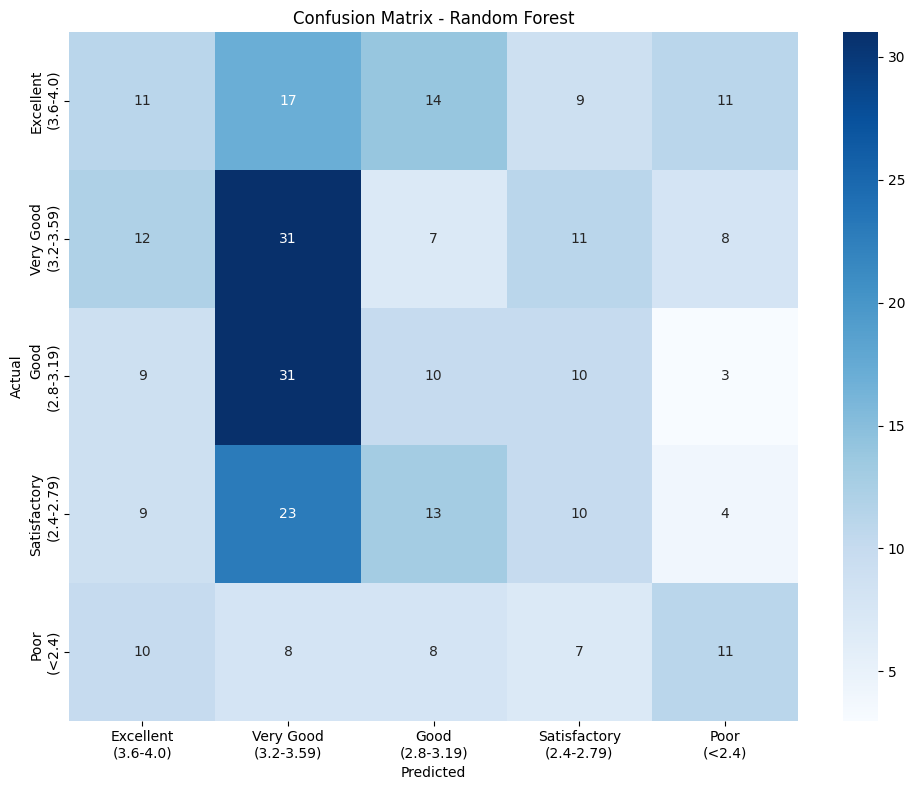


Classification Report - Random Forest
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.22      0.18      0.19        62
   Very Good (3.2-3.59)       0.28      0.45      0.35        69
        Good (2.8-3.19)       0.19      0.16      0.17        63
Satisfactory (2.4-2.79)       0.21      0.17      0.19        59
            Poor (<2.4)       0.30      0.25      0.27        44

               accuracy                           0.25       297
              macro avg       0.24      0.24      0.24       297
           weighted avg       0.24      0.25      0.24       297



In [8]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
print_classification_report(y_test, y_pred_rf, 'Random Forest')

---
## 6. Model 2: Gradient Boosting Classifier

In [9]:
print("Training Gradient Boosting Classifier...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    max_features='sqrt',
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

gb_model.fit(X_train, y_train)
result, y_pred_gb = evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Gradient Boosting Classifier...

Results:
  Model: Gradient Boosting
  Accuracy: 0.2559
  Macro F1-Score: 0.26
  Balanced Accuracy: 0.2537
  ROC-AUC: 0.5798


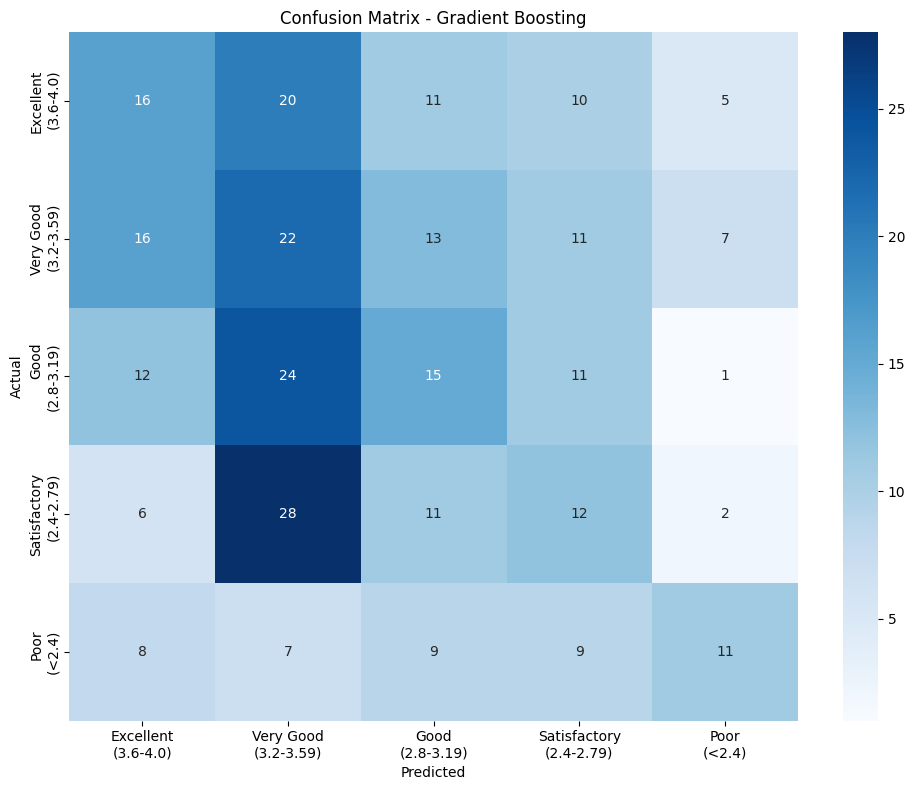


Classification Report - Gradient Boosting
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.28      0.26      0.27        62
   Very Good (3.2-3.59)       0.22      0.32      0.26        69
        Good (2.8-3.19)       0.25      0.24      0.25        63
Satisfactory (2.4-2.79)       0.23      0.20      0.21        59
            Poor (<2.4)       0.42      0.25      0.31        44

               accuracy                           0.26       297
              macro avg       0.28      0.25      0.26       297
           weighted avg       0.27      0.26      0.26       297



In [10]:
plot_confusion_matrix(y_test, y_pred_gb, 'Gradient Boosting')
print_classification_report(y_test, y_pred_gb, 'Gradient Boosting')

---
## 7. Model 3: XGBoost Classifier

In [11]:
print("Training XGBoost Classifier...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
result, y_pred_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training XGBoost Classifier...

Results:
  Model: XGBoost
  Accuracy: 0.266
  Macro F1-Score: 0.2624
  Balanced Accuracy: 0.2622
  ROC-AUC: 0.5927


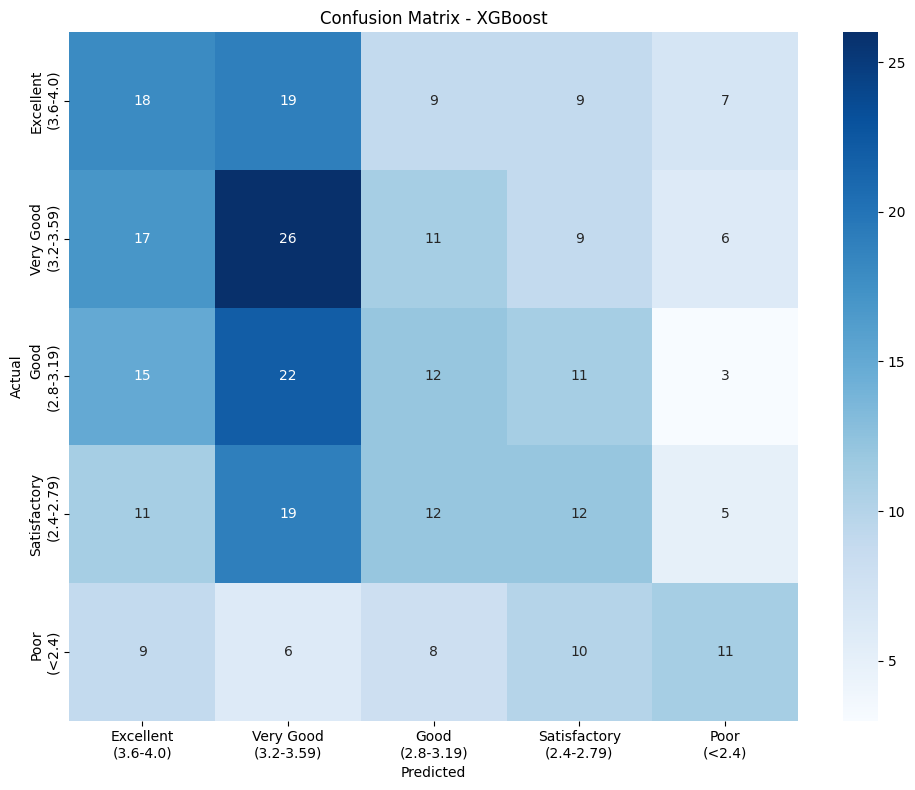


Classification Report - XGBoost
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.26      0.29      0.27        62
   Very Good (3.2-3.59)       0.28      0.38      0.32        69
        Good (2.8-3.19)       0.23      0.19      0.21        63
Satisfactory (2.4-2.79)       0.24      0.20      0.22        59
            Poor (<2.4)       0.34      0.25      0.29        44

               accuracy                           0.27       297
              macro avg       0.27      0.26      0.26       297
           weighted avg       0.27      0.27      0.26       297



In [12]:
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')
print_classification_report(y_test, y_pred_xgb, 'XGBoost')

---
## 8. Model 4: CatBoost Classifier

In [13]:
print("Training CatBoost Classifier...")

catboost_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)
result, y_pred_cat = evaluate_model(catboost_model, X_test, y_test, 'CatBoost')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training CatBoost Classifier...

Results:
  Model: CatBoost
  Accuracy: 0.2828
  Macro F1-Score: 0.2833
  Balanced Accuracy: 0.2825
  ROC-AUC: 0.5749


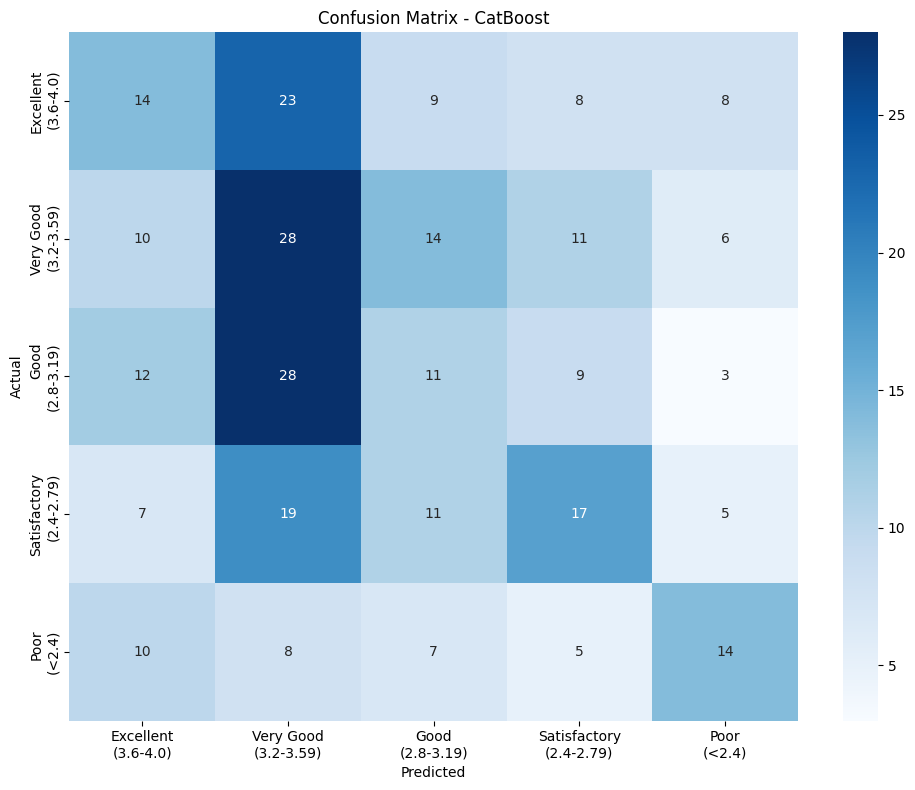


Classification Report - CatBoost
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.26      0.23      0.24        62
   Very Good (3.2-3.59)       0.26      0.41      0.32        69
        Good (2.8-3.19)       0.21      0.17      0.19        63
Satisfactory (2.4-2.79)       0.34      0.29      0.31        59
            Poor (<2.4)       0.39      0.32      0.35        44

               accuracy                           0.28       297
              macro avg       0.29      0.28      0.28       297
           weighted avg       0.29      0.28      0.28       297



In [14]:
plot_confusion_matrix(y_test, y_pred_cat, 'CatBoost')
print_classification_report(y_test, y_pred_cat, 'CatBoost')

---
## 9. Model 5: Logistic Regression

In [15]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=2000,
    C=0.5,
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
result, y_pred_lr = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Logistic Regression...

Results:
  Model: Logistic Regression
  Accuracy: 0.2862
  Macro F1-Score: 0.2851
  Balanced Accuracy: 0.2978
  ROC-AUC: 0.5616


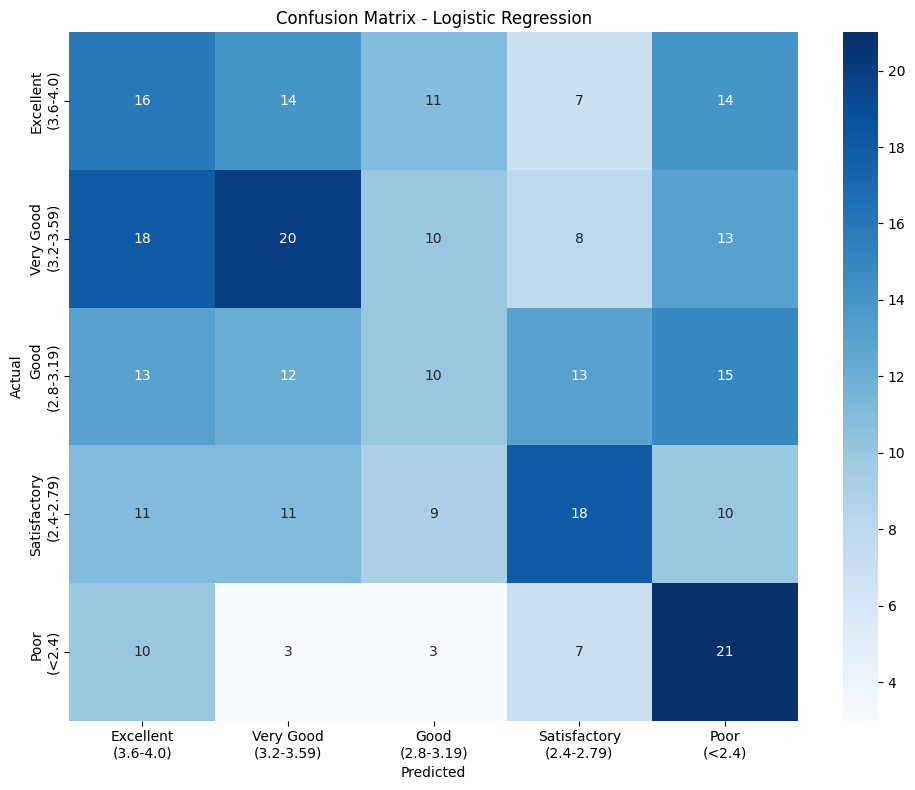


Classification Report - Logistic Regression
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.24      0.26      0.25        62
   Very Good (3.2-3.59)       0.33      0.29      0.31        69
        Good (2.8-3.19)       0.23      0.16      0.19        63
Satisfactory (2.4-2.79)       0.34      0.31      0.32        59
            Poor (<2.4)       0.29      0.48      0.36        44

               accuracy                           0.29       297
              macro avg       0.29      0.30      0.29       297
           weighted avg       0.29      0.29      0.28       297



In [16]:
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')
print_classification_report(y_test, y_pred_lr, 'Logistic Regression')

---
## 10. Model 6: Artificial Neural Network (PyTorch)

In [17]:
# Define Neural Network Architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(NeuralNetwork, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

print("Neural Network class defined.")

Neural Network class defined.


In [18]:
# Prepare data for PyTorch
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model
input_size = X_train.shape[1]
hidden_sizes = [128, 64, 32]
num_classes = 5  # 5 classes for Current_CGPA5

ann_model = NeuralNetwork(input_size, hidden_sizes, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

print(f"Model architecture:")
print(ann_model)

Model architecture:
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=5, bias=True)
  )
)


In [19]:
# Training loop
print("Training Neural Network...")
epochs = 100
train_losses = []

for epoch in range(epochs):
    ann_model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ann_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}")

print("\nTraining completed!")

Training Neural Network...
Epoch [20/100], Loss: 1.4933
Epoch [40/100], Loss: 1.3775
Epoch [60/100], Loss: 1.2957
Epoch [80/100], Loss: 1.2030
Epoch [100/100], Loss: 1.1198

Training completed!


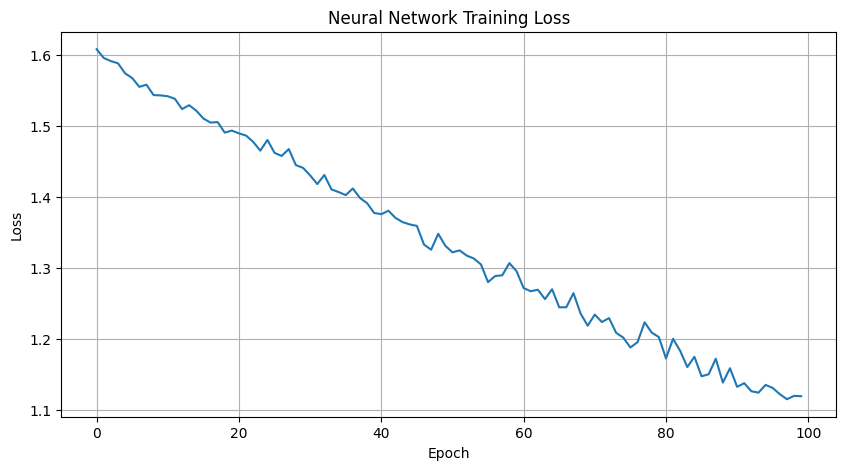

In [20]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [21]:
# Evaluate Neural Network
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    _, y_pred_ann = torch.max(outputs, 1)
    y_pred_ann = y_pred_ann.cpu().numpy()
    
    # Get probabilities for ROC-AUC
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_ann)
macro_f1 = f1_score(y_test, y_pred_ann, average='macro')
balanced_acc = balanced_accuracy_score(y_test, y_pred_ann)
roc_auc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

result = {
    'Model': 'Neural Network',
    'Accuracy': round(accuracy, 4),
    'Macro F1-Score': round(macro_f1, 4),
    'Balanced Accuracy': round(balanced_acc, 4),
    'ROC-AUC': round(roc_auc, 4)
}
all_results.append(result)

print(f"\nNeural Network Results:")
for key, value in result.items():
    print(f"  {key}: {value}")


Neural Network Results:
  Model: Neural Network
  Accuracy: 0.2088
  Macro F1-Score: 0.21
  Balanced Accuracy: 0.2101
  ROC-AUC: 0.5302


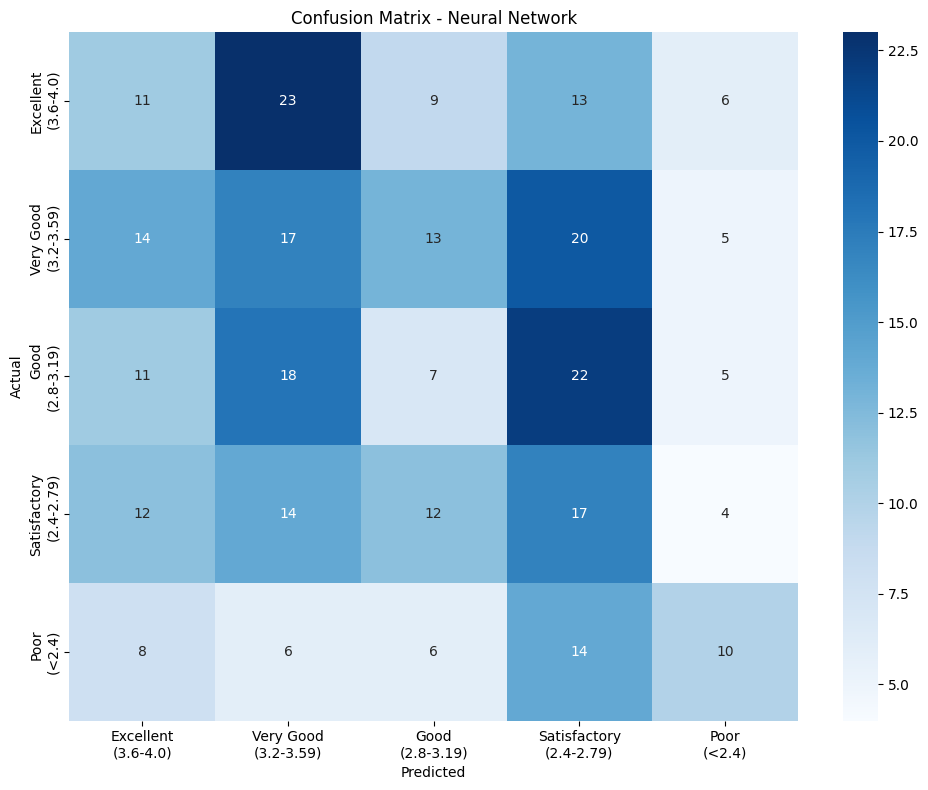


Classification Report - Neural Network
                         precision    recall  f1-score   support

    Excellent (3.6-4.0)       0.20      0.18      0.19        62
   Very Good (3.2-3.59)       0.22      0.25      0.23        69
        Good (2.8-3.19)       0.15      0.11      0.13        63
Satisfactory (2.4-2.79)       0.20      0.29      0.23        59
            Poor (<2.4)       0.33      0.23      0.27        44

               accuracy                           0.21       297
              macro avg       0.22      0.21      0.21       297
           weighted avg       0.21      0.21      0.21       297



In [22]:
plot_confusion_matrix(y_test, y_pred_ann, 'Neural Network')
print_classification_report(y_test, y_pred_ann, 'Neural Network')

---
## 11. Model Comparison

In [23]:
# Create comparison dataframe
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("="*80)
print("MODEL COMPARISON - 5-Class CGPA Prediction (Current_CGPA5)")
print("="*80)
print(results_df.to_string(index=False))

MODEL COMPARISON - 5-Class CGPA Prediction (Current_CGPA5)
              Model  Accuracy  Macro F1-Score  Balanced Accuracy  ROC-AUC
Logistic Regression    0.2862          0.2851             0.2978   0.5616
           CatBoost    0.2828          0.2833             0.2825   0.5749
            XGBoost    0.2660          0.2624             0.2622   0.5927
  Gradient Boosting    0.2559          0.2600             0.2537   0.5798
      Random Forest    0.2458          0.2351             0.2410   0.5675
     Neural Network    0.2088          0.2100             0.2101   0.5302


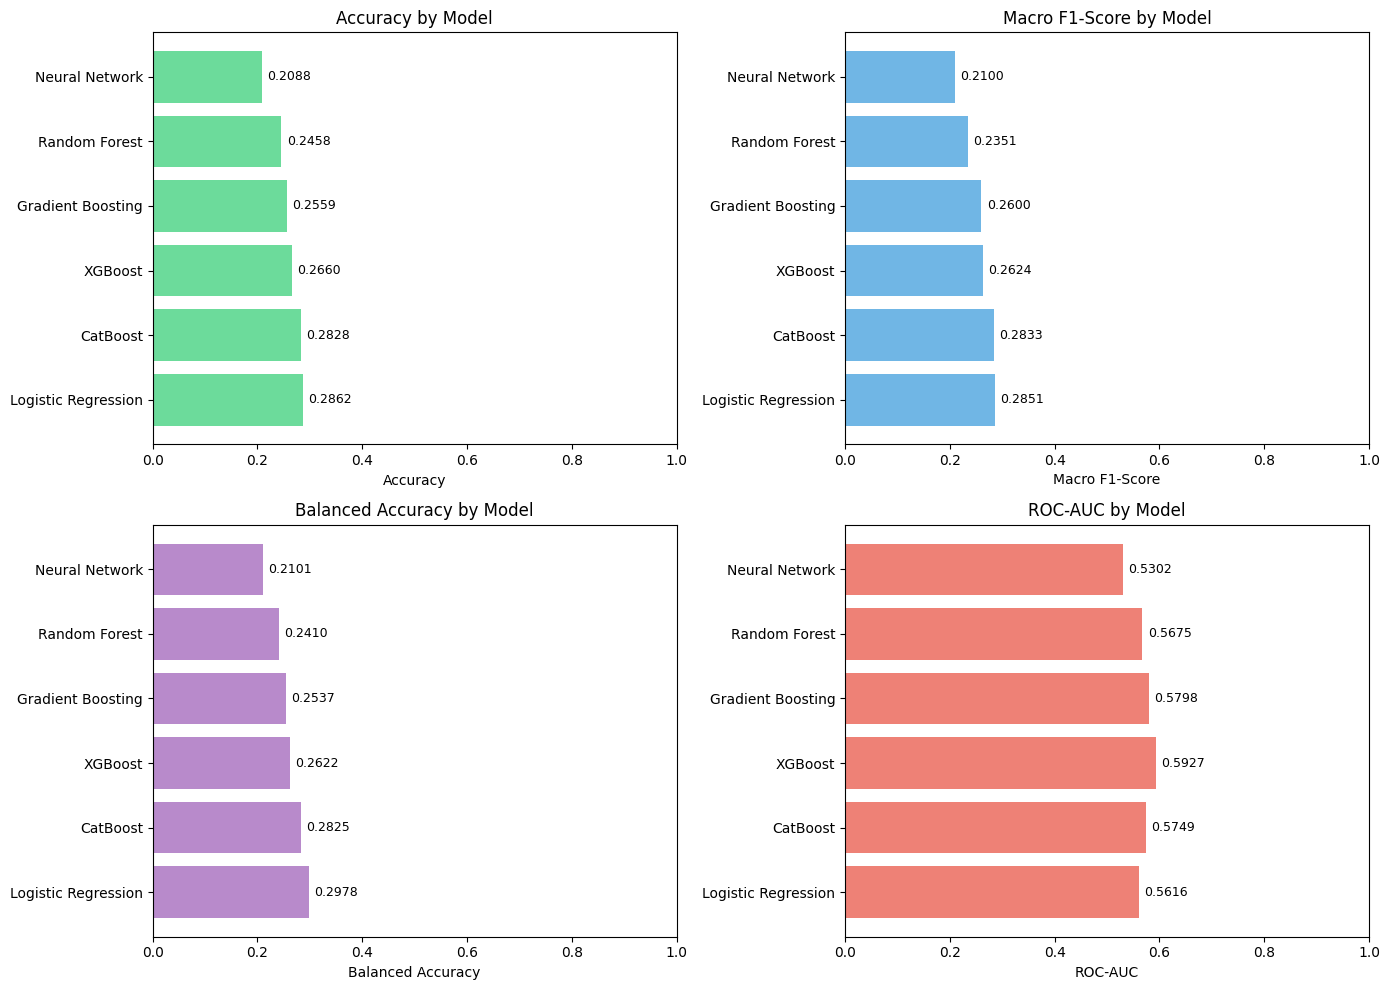


Figure saved to: ../images/model_comparison_5class_cgpa.png


In [24]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Macro F1-Score', 'Balanced Accuracy', 'ROC-AUC']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

for idx, (ax, metric, color) in enumerate(zip(axes.flat, metrics, colors)):
    if metric == 'ROC-AUC':
        # Handle 'N/A' values
        plot_df = results_df[results_df['ROC-AUC'] != 'N/A'].copy()
        plot_df['ROC-AUC'] = plot_df['ROC-AUC'].astype(float)
        values = plot_df[metric].values
        models = plot_df['Model'].values
    else:
        values = results_df[metric].values
        models = results_df['Model'].values
    
    bars = ax.barh(models, values, color=color, alpha=0.7)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.set_xlim(0, 1)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/model_comparison_5class_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/model_comparison_5class_cgpa.png")

In [25]:
# Save results to CSV
results_df.to_csv('../results/5class_cgpa_model_results.csv', index=False)
print("Results saved to: ../results/5class_cgpa_model_results.csv")
print("\n" + "="*80)
print("EXPERIMENT COMPLETE!")
print("="*80)

Results saved to: ../results/5class_cgpa_model_results.csv

EXPERIMENT COMPLETE!


## 12. Summary

This notebook ran 6 machine learning models on the GAN-augmented balanced normalized dataset:

1. **Random Forest** - Ensemble of decision trees
2. **Gradient Boosting** - Sequential boosting
3. **XGBoost** - Optimized gradient boosting
4. **CatBoost** - Gradient boosting with categorical support
5. **Logistic Regression** - Linear model for classification
6. **Neural Network** - Deep learning with PyTorch

### Key Points:
- Data is already normalized (values between 0 and 1)
- Classes are balanced using GAN-generated synthetic data
- No feature engineering applied - plain model runs
- Target: Current_CGPA5 (5 classes)

---
## 13. Feature Importance Visualization

Visualizing which features contribute most to predictions for each model.

In [26]:
# Get feature importances from tree-based models
feature_importance_dict = {}

# Random Forest
feature_importance_dict['Random Forest'] = rf_model.feature_importances_

# Gradient Boosting
feature_importance_dict['Gradient Boosting'] = gb_model.feature_importances_

# XGBoost
feature_importance_dict['XGBoost'] = xgb_model.feature_importances_

# CatBoost
feature_importance_dict['CatBoost'] = catboost_model.feature_importances_

# Logistic Regression (use absolute coefficients averaged across classes)
lr_importance = np.mean(np.abs(lr_model.coef_), axis=0)
lr_importance = lr_importance / lr_importance.sum()  # Normalize
feature_importance_dict['Logistic Regression'] = lr_importance

print("Feature importances extracted for all models!")

Feature importances extracted for all models!


In [27]:
# Create feature importance dataframe
importance_df = pd.DataFrame(feature_importance_dict, index=feature_cols)
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("Top 15 Most Important Features (Averaged across models):")
print("="*60)
print(importance_df['Average'].head(15).to_string())
print("\nBottom 5 Least Important Features:")
print(importance_df['Average'].tail(5).to_string())

Top 15 Most Important Features (Averaged across models):
Rate_Sleep_Quality                    1.543769
Focus_on_Academic_Task                1.468451
Struggle_to_Sleep                     1.426062
Sleepiness_During_Class               1.379263
Main_Reason_for_Insufficient_Sleep    1.362889
Impact_of_Sleep_on_Academic           1.297758
Daily_Academics_Time_Spend            1.260756
Where_live                            1.175365
AVG_Sleep_Per_Night                   1.025748
Sleep_Condition                       0.858775
Class_Attendance                      0.833922
Daytime_Nap                           0.798067
Age                                   0.781012
Regular_WakeUp_Time                   0.665664
Consume_Caffeine_Night                0.561335

Bottom 5 Least Important Features:
Electronic_Devices_Before_Bed     0.265287
Sacrifices_Sleep_for_Academics    0.264465
Holiday_WakeUp_Time               0.204091
Have_Regular_Bed_Time             0.154047
Sleep_Affecting_Drugs         

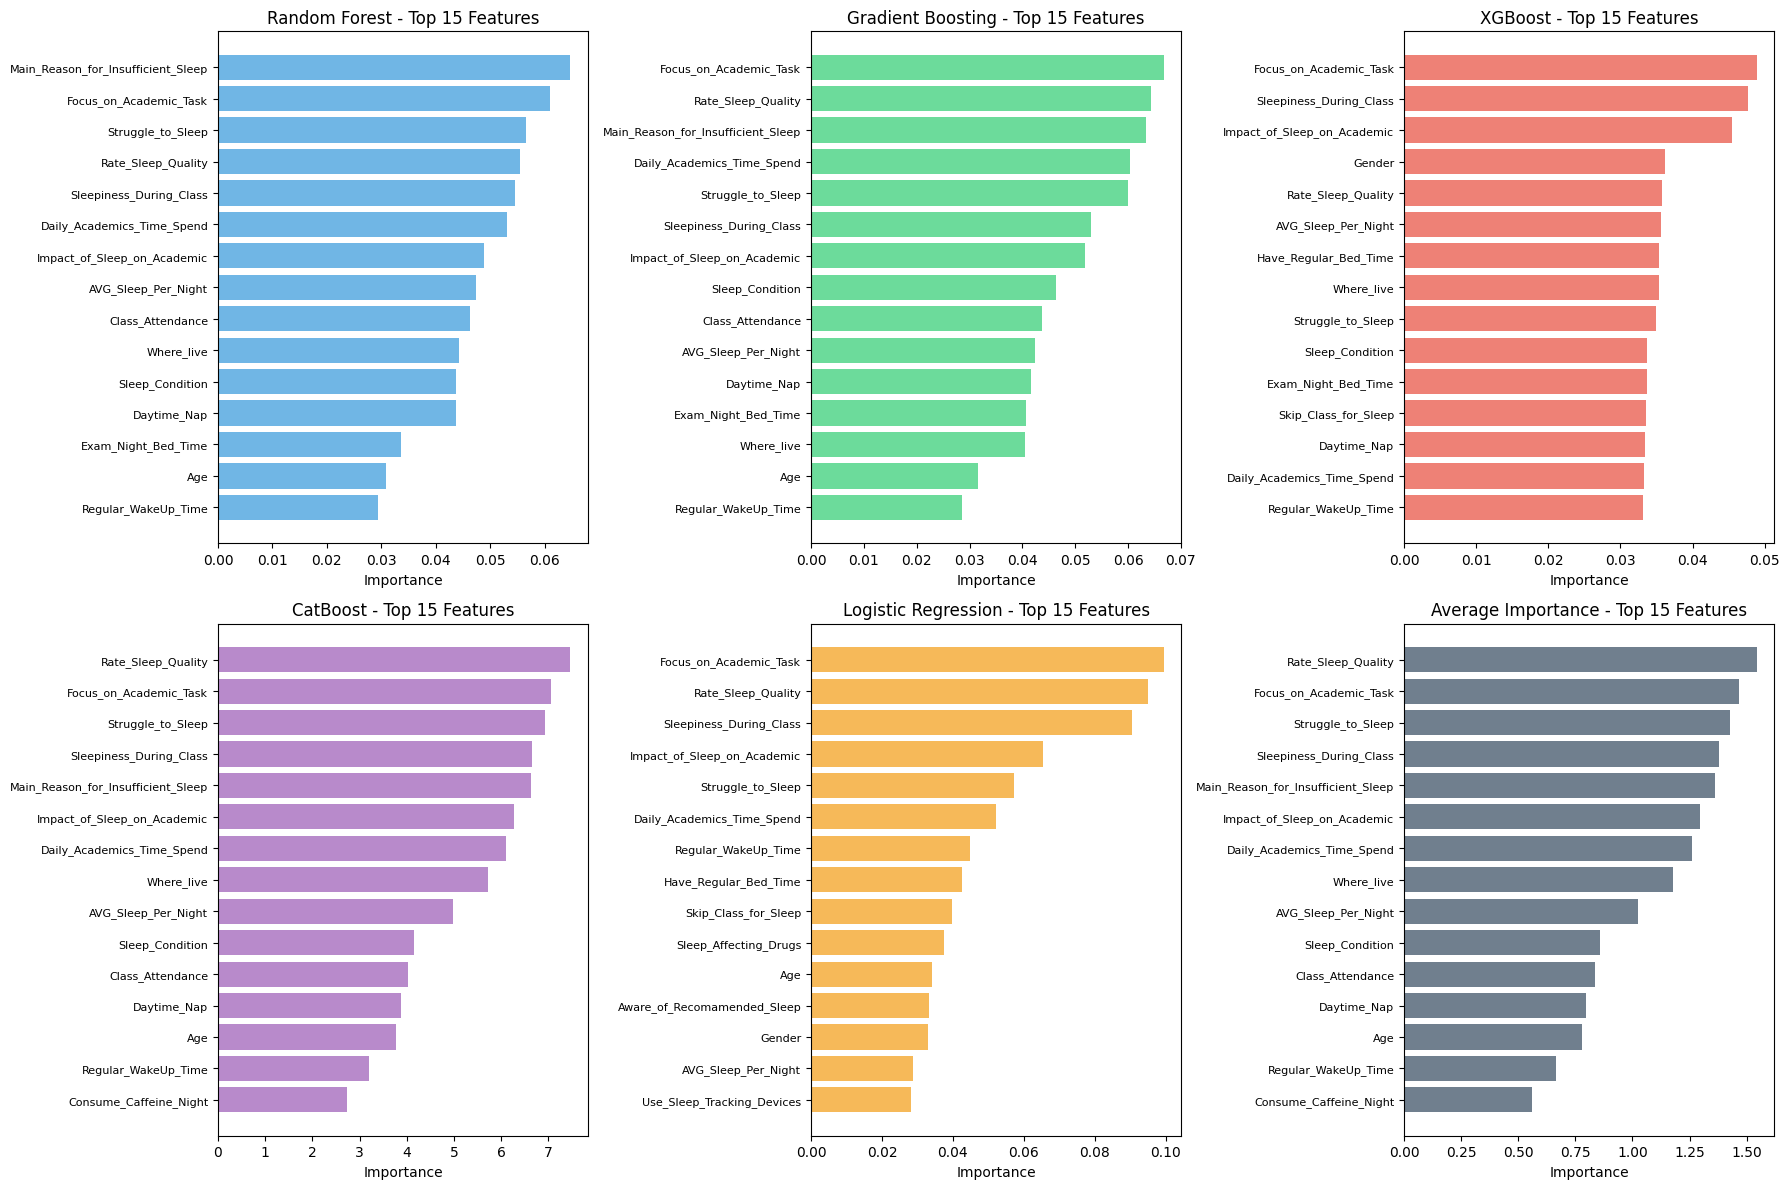


Figure saved to: ../images/feature_importance_5class_all_models.png


In [28]:
# Visualize feature importance for each model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
models_to_plot = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost', 'Logistic Regression']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for idx, (ax, model_name, color) in enumerate(zip(axes.flat[:5], models_to_plot, colors)):
    # Get top 15 features for this model
    model_importance = importance_df[model_name].sort_values(ascending=True).tail(15)
    
    ax.barh(model_importance.index, model_importance.values, color=color, alpha=0.7)
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} - Top 15 Features')
    ax.tick_params(axis='y', labelsize=8)

# Average importance in the last subplot
ax = axes.flat[5]
avg_importance = importance_df['Average'].sort_values(ascending=True).tail(15)
ax.barh(avg_importance.index, avg_importance.values, color='#34495e', alpha=0.7)
ax.set_xlabel('Importance')
ax.set_title('Average Importance - Top 15 Features')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../images/feature_importance_5class_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/feature_importance_5class_all_models.png")

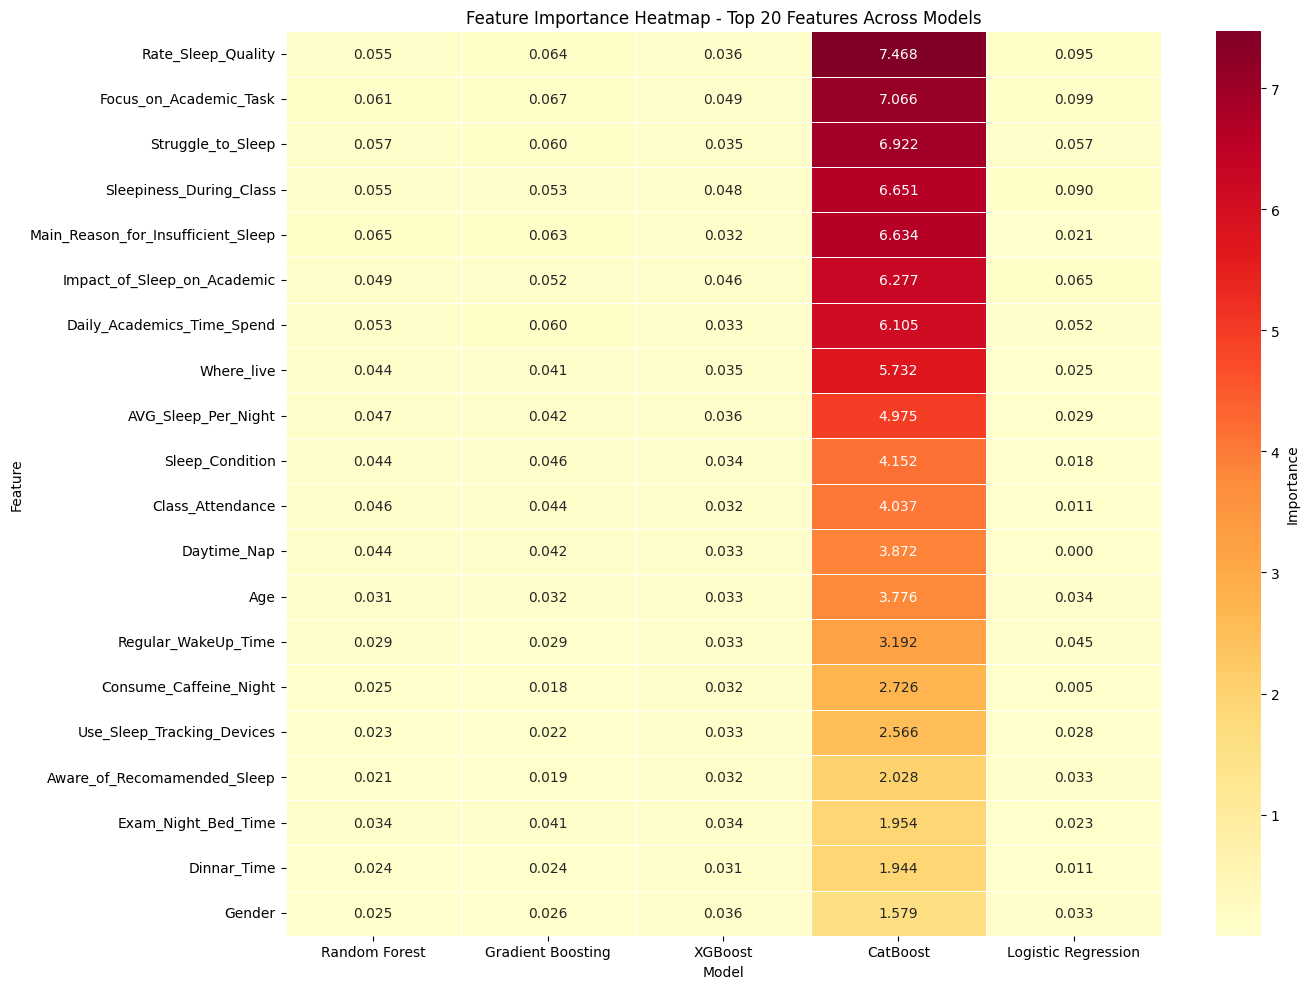


Figure saved to: ../images/feature_importance_5class_heatmap.png


In [29]:
# Heatmap of feature importance across all models
plt.figure(figsize=(14, 10))

# Get top 20 features by average importance
top_features = importance_df['Average'].sort_values(ascending=False).head(20).index
heatmap_data = importance_df.loc[top_features, models_to_plot]

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Importance'})
plt.title('Feature Importance Heatmap - Top 20 Features Across Models')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../images/feature_importance_5class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/feature_importance_5class_heatmap.png")

In [30]:
# Save feature importance to CSV
importance_df.to_csv('../results/feature_importance_5class_all_models.csv')
print("Feature importance saved to: ../results/feature_importance_5class_all_models.csv")

# Summary of most important features
print("\n" + "="*60)
print("FEATURE IMPORTANCE SUMMARY")
print("="*60)
print("\nTop 10 Most Influential Features (by average importance):")
for i, (feature, importance) in enumerate(importance_df['Average'].head(10).items(), 1):
    print(f"  {i}. {feature}: {importance:.4f}")

Feature importance saved to: ../results/feature_importance_5class_all_models.csv

FEATURE IMPORTANCE SUMMARY

Top 10 Most Influential Features (by average importance):
  1. Rate_Sleep_Quality: 1.5438
  2. Focus_on_Academic_Task: 1.4685
  3. Struggle_to_Sleep: 1.4261
  4. Sleepiness_During_Class: 1.3793
  5. Main_Reason_for_Insufficient_Sleep: 1.3629
  6. Impact_of_Sleep_on_Academic: 1.2978
  7. Daily_Academics_Time_Spend: 1.2608
  8. Where_live: 1.1754
  9. AVG_Sleep_Per_Night: 1.0257
  10. Sleep_Condition: 0.8588


---
## 14. 📊 Model Performance Summary Table

Comprehensive comparison of all models with key metrics.

In [31]:
# ============================================================================
# COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================================

from sklearn.metrics import precision_score, recall_score

print("Creating comprehensive model comparison table...\n")

# Store results for all models
all_model_results = []

# ===== 1. GRADIENT BOOSTING =====
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_prec = precision_score(y_test, y_pred_gb, average='macro')
gb_rec = recall_score(y_test, y_pred_gb, average='macro')
gb_f1 = f1_score(y_test, y_pred_gb, average='macro')
gb_roc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': round(gb_acc, 4),
    'Precision': round(gb_prec, 4),
    'Recall': round(gb_rec, 4),
    'F1-Score': round(gb_f1, 4),
    'ROC-AUC': round(gb_roc, 4)
})

# ===== 2. XGBOOST =====
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb, average='macro')
xgb_rec = recall_score(y_test, y_pred_xgb, average='macro')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_roc = roc_auc_score(y_test, xgb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'XGBoost',
    'Accuracy': round(xgb_acc, 4),
    'Precision': round(xgb_prec, 4),
    'Recall': round(xgb_rec, 4),
    'F1-Score': round(xgb_f1, 4),
    'ROC-AUC': round(xgb_roc, 4)
})

# ===== 3. CATBOOST =====
cb_acc = accuracy_score(y_test, y_pred_cat)
cb_prec = precision_score(y_test, y_pred_cat, average='macro')
cb_rec = recall_score(y_test, y_pred_cat, average='macro')
cb_f1 = f1_score(y_test, y_pred_cat, average='macro')
cb_roc = roc_auc_score(y_test, catboost_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'CatBoost',
    'Accuracy': round(cb_acc, 4),
    'Precision': round(cb_prec, 4),
    'Recall': round(cb_rec, 4),
    'F1-Score': round(cb_f1, 4),
    'ROC-AUC': round(cb_roc, 4)
})

# ===== 4. RANDOM FOREST =====
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_rec = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Random Forest',
    'Accuracy': round(rf_acc, 4),
    'Precision': round(rf_prec, 4),
    'Recall': round(rf_rec, 4),
    'F1-Score': round(rf_f1, 4),
    'ROC-AUC': round(rf_roc, 4)
})

# ===== 5. LOGISTIC REGRESSION =====
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='macro')
lr_rec = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(lr_acc, 4),
    'Precision': round(lr_prec, 4),
    'Recall': round(lr_rec, 4),
    'F1-Score': round(lr_f1, 4),
    'ROC-AUC': round(lr_roc, 4)
})

# ===== 6. NEURAL NETWORK =====
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

ann_acc = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='macro')
ann_rec = recall_score(y_test, y_pred_ann, average='macro')
ann_f1 = f1_score(y_test, y_pred_ann, average='macro')
ann_roc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Neural Network',
    'Accuracy': round(ann_acc, 4),
    'Precision': round(ann_prec, 4),
    'Recall': round(ann_rec, 4),
    'F1-Score': round(ann_f1, 4),
    'ROC-AUC': round(ann_roc, 4)
})

# Create DataFrame and sort by accuracy
final_comparison_df = pd.DataFrame(all_model_results)
final_comparison_df = final_comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Add rank
final_comparison_df.insert(0, 'Rank', range(1, len(final_comparison_df) + 1))

# Display table
print("=" * 95)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON - 5-CLASS CGPA PREDICTION")
print("=" * 95)
print(final_comparison_df.to_string(index=False))
print("=" * 95)

# Summary
best_model = final_comparison_df.iloc[0]['Model']
best_acc = final_comparison_df.iloc[0]['Accuracy']

print(f"\n🏆 Best Model: {best_model}")
print(f"📊 Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"📈 Models Compared: {len(final_comparison_df)}")
print("=" * 95)

# Save results
final_comparison_df.to_csv('../results/final_5class_model_comparison.csv', index=False)
print("\n✓ Results saved to: ../results/final_5class_model_comparison.csv")

Creating comprehensive model comparison table...

COMPREHENSIVE MODEL PERFORMANCE COMPARISON - 5-CLASS CGPA PREDICTION
 Rank               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    1 Logistic Regression    0.2862     0.2857  0.2978    0.2851   0.5616
    2            CatBoost    0.2828     0.2937  0.2825    0.2833   0.5749
    3             XGBoost    0.2660     0.2699  0.2622    0.2624   0.5927
    4   Gradient Boosting    0.2559     0.2795  0.2537    0.2600   0.5798
    5       Random Forest    0.2458     0.2400  0.2410    0.2351   0.5675
    6      Neural Network    0.2088     0.2189  0.2101    0.2100   0.5302

🏆 Best Model: Logistic Regression
📊 Best Accuracy: 0.2862 (28.62%)
📈 Models Compared: 6

✓ Results saved to: ../results/final_5class_model_comparison.csv
